# Phase 1 — Synthetic PHI on Lung Ultrasound (Batch)

**Author:** Lakshmi Mahabaleshwara

**Purpose:** To demonstrate the core idea of the synthetic PHI generation pipeline end-to-end on real ultrasound images, processed as a batch.

**Inputs:** a folder (or nested folders) of lung POCUS JPGs (e.g., from [OpenPOCUS](https://github.com/kumarandre/OpenPOCUS)).

**Outputs:** the output mirrors the input folder structure. For every input subfolder, we produce a matching output folder containing:
* `dicom/` — the burned DICOMs for that folder's images
* `run_manifest.csv` — one row per input image (status, paths, case_uuid, seed)
* `phi_overlays.csv` — one row per burned PHI overlay (bbox, value, category, matching DICOM tag)
*   Synthetic PHI gets rendered onto real ultrasound pixels.

## Why synthetic PHI data?

Ultrasound images carry Protected Health Information (PHI) in two places: burned into the pixels (patient name, MRN, date overlaid on the scan) and stored in the DICOM header tags. Removing that PHI safely is the goal, and synthetic data with **deliberately planted, fully-known PHI** makes that goal testable.

**A. Testing de-identification software.**
De-id tools redact pixels and scrub header tags before images leave the hospital. Those tools must prove they work *before* touching real patient data, but real PHI is exactly what cannot be risked in a test. Planted-PHI images solve this: since every identifier and its location is known in advance, a test can confirm whether a tool removed all of it, and flag anything it wrongly left behind or wrongly destroyed.

**B. Training AI de-identification models.**
A model that learns to find and remove PHI needs examples: images containing PHI, each paired with an answer key marking where the PHI sits. Real PHI cannot be labeled at scale or shared for model development.

## Pipeline overview
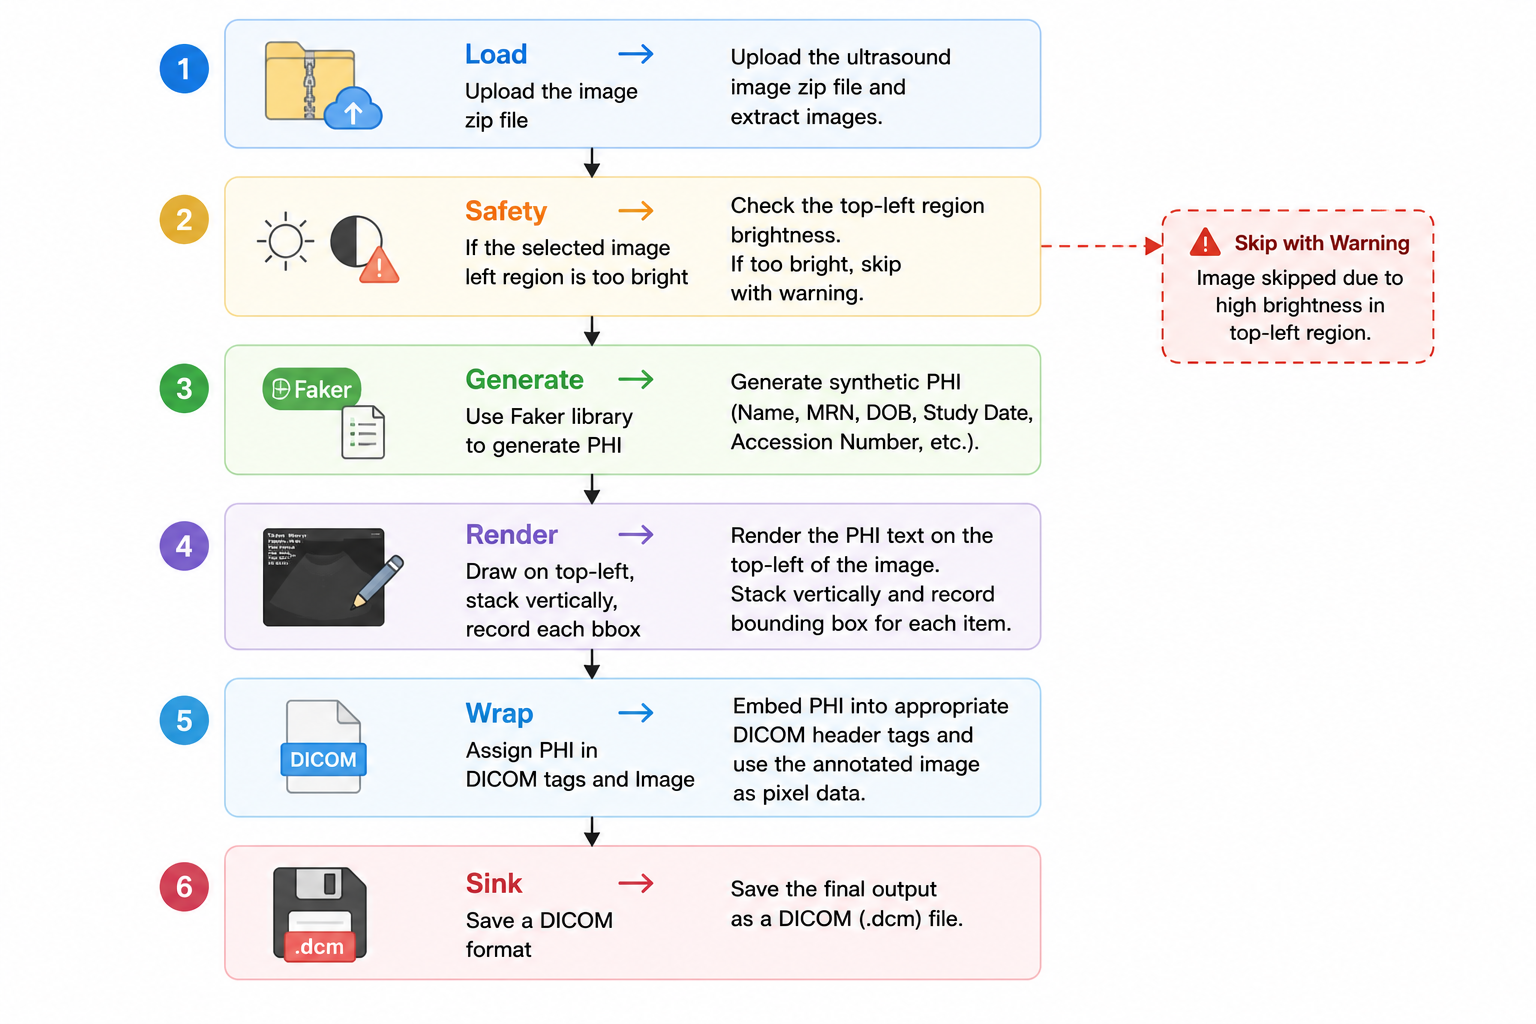

## 1. Setup

In [1]:
# Install dependencies.
!pip install monai pydicom pillow faker numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.1 MB/s eta 0:00:00


In [5]:
from pathlib import Path
import json
import hashlib
import datetime as dt
import random
import uuid

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from faker import Faker

from monai.transforms import LoadImaged, EnsureChannelFirstd, Compose

import pydicom
from pydicom.dataset import Dataset, FileDataset, FileMetaDataset
from pydicom.uid import generate_uid, ExplicitVRLittleEndian

## 1.1. Choose how to load input images

Pick one input method by setting `INPUT_METHOD` in the cell below, then run it. Only the chosen path executes.

| `INPUT_METHOD` | Method | What happens |
|---|---|---|
| `1` | **Colab upload** | A file picker opens. Upload a `.zip` of lung POCUS images (subfolders preserved). Extracts to `/content/data/input`. |
| `2` | **Manual / local folder** | No action — place images under the input directory yourself (`/content/data/input` on Colab, `./data/input` locally) before running section 2. |
| `3` | **Stanford Box** | Downloads a public Box file from `BOX_FILE_LINK` into `/content/data/input`. Auto-extracts if it is a `.zip`. |

All three land images in the same input directory, which section 2 picks up automatically.

In [3]:
# ============================================================
#  CHOOSE INPUT METHOD:  1 = Colab upload | 2 = manual | 3 = Box
# ============================================================
INPUT_METHOD = 1

In [4]:
# --- Detect environment ---
IS_COLAB = False
try:
    import google.colab  # noqa: F401
    IS_COLAB = True
except ImportError:
    pass

import zipfile
import shutil
import re
import urllib.request

# Input lands here regardless of method. Section 2 reads from the same path.
INPUT_TARGET = Path("/content/data/input") if IS_COLAB else Path("./data/input")

# Box file link (used only when INPUT_METHOD == 3). Public single-file link:
#   https://stanfordmedicine.app.box.com/s/<TOKEN>/file/<FILE_ID>
BOX_FILE_LINK = "https://stanfordmedicine.app.box.com/s/ajv4y3fv5i6mhs345mwhbvkg80cuvzcc/file/2083355562839"


def _summarize_input(target: Path) -> None:
    """Count and preview the image files now present under target."""
    found = [
        p for p in target.rglob("*")
        if p.is_file()
        and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
        and "__MACOSX" not in p.parts
        and not p.name.startswith(".")
    ]
    print(f"\n\u2713 {len(found)} image(s) under {target}")
    for p in found[:5]:
        print(f"   {p.relative_to(target)}")
    if len(found) > 5:
        print(f"   ... and {len(found) - 5} more")


def method_1_colab_upload() -> None:
    """Open a Colab file picker; accept a .zip or loose images."""
    if not IS_COLAB:
        print("INPUT_METHOD = 1 requires Colab. On local, use INPUT_METHOD = 2.")
        return
    from google.colab import files

    if INPUT_TARGET.exists():
        shutil.rmtree(INPUT_TARGET)          # fresh start on re-run
    INPUT_TARGET.mkdir(parents=True, exist_ok=True)

    print("Pick the .zip containing your lung POCUS images...")
    uploaded = files.upload()
    if not uploaded:
        print("\u26a0\ufe0f  No file selected. Re-run when ready.")
        return

    for fname in uploaded:
        fpath = Path(fname)
        if fpath.suffix.lower() == ".zip":
            print(f"Extracting {fname} \u2192 {INPUT_TARGET}")
            with zipfile.ZipFile(fpath) as z:
                z.extractall(INPUT_TARGET)
            fpath.unlink()
        else:
            shutil.move(fname, INPUT_TARGET / fname)
    _summarize_input(INPUT_TARGET)


def method_2_manual() -> None:
    """No download — user places files under INPUT_TARGET themselves."""
    INPUT_TARGET.mkdir(parents=True, exist_ok=True)
    print(f"Manual mode. Place input images under: {INPUT_TARGET.resolve()}")
    if any(INPUT_TARGET.rglob("*")):
        _summarize_input(INPUT_TARGET)
    else:
        print("(directory is currently empty)")


def method_3_box() -> None:
    """Download a public Box file into /content/data/input (or ./data/input)."""
    INPUT_TARGET.mkdir(parents=True, exist_ok=True)

    m = re.search(r"/s/([A-Za-z0-9]+)/file/(\d+)", BOX_FILE_LINK)
    if not m:
        raise ValueError(
            "BOX_FILE_LINK not in form .../s/<TOKEN>/file/<FILE_ID>. "
            "Open the file in Box, copy the address-bar URL, and retry."
        )
    shared_token, file_id = m.group(1), m.group(2)
    host = re.match(r"https?://([^/]+)", BOX_FILE_LINK).group(1)
    dl_url = (
        f"https://{host}/index.php?rm=box_download_shared_file"
        f"&shared_name={shared_token}&file_id=f_{file_id}"
    )

    print(f"Downloading Box file_id={file_id} \u2192 {INPUT_TARGET} ...")
    req = urllib.request.Request(dl_url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=300) as resp:
        disp = resp.headers.get("Content-Disposition", "")
        fm = re.search(r'filename="?([^"]+)"?', disp)
        fname = fm.group(1) if fm else f"box_{file_id}.bin"
        dest = INPUT_TARGET / fname

        total = resp.headers.get("Content-Length")
        total = int(total) if total and total.isdigit() else None
        total_mb = (total / 1_048_576) if total else None

        downloaded = 0
        chunk_size = 1024 * 256          # 256 KB chunks
        last_report = 0
        print(f"   file: {fname}" + (f"  ({total_mb:.1f} MB)" if total_mb else "  (size unknown)"))

        with open(dest, "wb") as fh:
            while True:
                chunk = resp.read(chunk_size)
                if not chunk:
                    break
                fh.write(chunk)
                downloaded += len(chunk)
                mb = downloaded / 1_048_576
                # Report every ~2 MB so the cell visibly progresses
                if mb - last_report >= 2 or not chunk:
                    if total_mb:
                        pct = 100 * downloaded / total
                        bar_len = 24
                        filled = int(bar_len * downloaded / total)
                        bar = "\u2588" * filled + "\u2500" * (bar_len - filled)
                        print(f"\r   [{bar}] {mb:6.1f} / {total_mb:.1f} MB  ({pct:5.1f}%)", end="", flush=True)
                    else:
                        print(f"\r   downloaded {mb:6.1f} MB ...", end="", flush=True)
                    last_report = mb
        print()  # newline after the progress line
    print(f"\u2713 Saved {dest}  ({downloaded / 1_048_576:.1f} MB)")

    if dest.suffix.lower() == ".zip":
        print(f"Extracting {dest.name} ...")
        with zipfile.ZipFile(dest) as zf:
            zf.extractall(INPUT_TARGET)
        dest.unlink()
    _summarize_input(INPUT_TARGET)


# --- Dispatch on the chosen method ---
if INPUT_METHOD == 1:
    method_1_colab_upload()
elif INPUT_METHOD == 2:
    method_2_manual()
elif INPUT_METHOD == 3:
    method_3_box()
else:
    raise ValueError(f"INPUT_METHOD must be 1, 2, or 3 (got {INPUT_METHOD!r})")


Pick the .zip containing your lung POCUS images...


Saving lung sample.zip to lung sample.zip
Extracting lung sample.zip → /content/data/input

✓ 4994 image(s) under /content/data/input
   lung sample/processed_1163_images_batch(1)/images/image_289_ED01_z08_frame_000201.jpg
   lung sample/processed_1163_images_batch(1)/images/image_316_ED01_z08_frame_000228.jpg
   lung sample/processed_1163_images_batch(1)/images/image_1035_ED01_z10_frame_000157.jpg
   lung sample/processed_1163_images_batch(1)/images/image_1021_ED01_z10_frame_000143.jpg
   lung sample/processed_1163_images_batch(1)/images/image_339_ED01_z08_frame_000251.jpg
   ... and 4989 more


In [6]:
# --- input / output paths ---
# INPUT_TARGET was set in the input-method cell above; reuse it so the two can never drift apart.
INPUT_DIR = INPUT_TARGET
OUTPUT_DIR = Path("/content/data/output") if IS_COLAB else Path("./data/output")

## 2. Configuration

All configuration related to the PHI information (Example : Font size, DICOM tags, and other info) is given here.

### Selecting the DICOM color mode

The `OUTPUT_COLOR_MODE` knob controls how pixels are stored in the multi-frame DICOM:

| Value | Stored as |  |  |
|---|---|---|---|
| `"grayscale"` | `MONOCHROME2`, 1 channel per pixel|
| `"rgb"` | `RGB`, 3 channels per pixel |

**What changes in RGB mode:**
- DICOM tags update: `SamplesPerPixel = 3`, `PhotometricInterpretation = "RGB"`, `PlanarConfiguration = 0`, `LossyImageCompression = "00"`.
- Pixel data layout becomes `(num_frames, H, W, 3)` — three times the bytes of grayscale.
- The manufacturer overlay line is rendered in `MANUFACTURER_COLOR` (warm yellow). All PHI text remains white.
- Channel equality check on the output: `R != G != B` at the manufacturer text pixels, `R == G == B` everywhere else (the fan stays grayscale-replicated).

In [7]:
# --- DICOM output colorspace ---
OUTPUT_COLOR_MODE = "rgb"   # "grayscale" (1ch MONOCHROME2) or "rgb" (3ch RGB)

In [8]:
RUN_ID = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = OUTPUT_DIR / RUN_ID
QUARANTINE_DIR = RUN_DIR / "_quarantine"  # only top-level dir created up front; per-folder dirs are created lazily

# --- reproducibility ---
SEED = 42
PIPELINE_VERSION = "synthetic phi"

# --- burn region (top-left corner — reliably outside fan for lung POCUS) ---
BURN_REGION_X = 5                        # pixels from left edge
BURN_REGION_Y = 5                        # pixels from top edge
BURN_REGION_W = 250                       # max width reserved for PHI text
BURN_REGION_H = 100                       # max height reserved for PHI text
BRIGHTNESS_SKIP_THRESHOLD = 30            # if burn region mean > this, skip image

# --- text rendering ---
FONT_SIZE = 16
LINE_GAP = 6
TEXT_COLOR = 255                          # white on grayscale

# Font search paths — checked in order, first existing one wins.
# Covers Colab/Ubuntu, macOS, Windows, and matplotlib's bundled fonts.
FONT_CANDIDATES = [
    # Colab / Ubuntu / Debian — DejaVu ships standard
    "/usr/share/fonts/truetype/dejavu/DejaVuSansMono-Bold.ttf",
    "/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",
    "/usr/share/fonts/truetype/liberation/LiberationMono-Bold.ttf",
    "/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf",
    # Newer Ubuntu locations
    "/usr/share/fonts/TTF/DejaVuSansMono-Bold.ttf",
    "/usr/share/fonts/TTF/DejaVuSansMono.ttf",
    # macOS
    "/Library/Fonts/Courier New Bold.ttf",
    "/System/Library/Fonts/Menlo.ttc",
    "/System/Library/Fonts/Monaco.ttf",
    # Windows
    "C:/Windows/Fonts/consolab.ttf",
    "C:/Windows/Fonts/consola.ttf",
    "C:/Windows/Fonts/cour.ttf",
]

# --- synthetic PHI generation ---
INSTITUTION_POOL = [
    "North Plains Medical Center",
    "Riverbend University Hospital",
    "Coastal Regional Health",
]

# --- file glob ---
IMAGE_GLOB = ["*.jpg", "*.jpeg", "*.png"]

# Make output root + quarantine. Per-folder output dirs are created on demand in process_one().
RUN_DIR.mkdir(parents=True, exist_ok=True)
QUARANTINE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run ID: {RUN_ID}")
print(f"Output: {RUN_DIR.resolve()}")
print(f"OUTPUT_COLOR_MODE = {OUTPUT_COLOR_MODE!r}")

# --- filename parsing (config-driven; swap pattern when convention changes) ---
# Pattern MUST define named groups: patient, zone, frame
FILENAME_PATTERN = r"image_\d+_(?P<patient>[A-Za-z0-9]+)_z(?P<zone>\d+)_frame_(?P<frame>\d+)"

# --- multi-frame cine timing ---
FRAME_TIME_MS = "33.3"   # ms between frames (~30 fps); adjust if real rate known

# --- de-identified PatientID assignment ---
# Source patient IDs (e.g. "ED01") are mapped to synthetic de-id IDs (e.g. "DEID-0001").
DEID_ID_PREFIX = "DEID-"

# Mapping file: source patient id -> de-id PatientID (written at run root)
ID_MAPPING_PATH = RUN_DIR / "id_mapping.csv"


# ===================================================================
# RGB-mode visible color element (single)
# ===================================================================
# Keep DICOM RGB format support, and only the
# manufacturer-name line is rendered in color; everything else stays in
# grayscale (white-on-black). In RGB mode the manufacturer line is the
# one visibly-colored element confirming the file genuinely carries
# color content (R != G != B at the manufacturer text pixels).
MANUFACTURER_NAME = "SYNTHETIC-DEID-TUTORIAL"
MANUFACTURER_COLOR = (255, 220, 120)   # warm yellow — used in RGB mode only


Run ID: 20260605_103423
Output: /content/data/output/20260605_103423
OUTPUT_COLOR_MODE = 'rgb'


## 3. Helper: Deterministic seeding

Same image + same global seed → same synthetic PHI, every run.

In [9]:
def case_seed(global_seed: int, source_id: str) -> int:
    """Per-image deterministic seed derived from global seed and source path."""
    h = hashlib.sha256(f"{global_seed}|{source_id}".encode()).hexdigest()
    return int(h[:8], 16)

def load_font():
    for path in FONT_CANDIDATES:
        if Path(path).exists():
            print(f"Using Font: {path}")
            return ImageFont.truetype(path, FONT_SIZE)
    print("⚠️  No system monospace font found; falling back to PIL default (small).")
    return ImageFont.load_default()

FONT = load_font()

Using Font: /usr/share/fonts/truetype/liberation/LiberationMono-Bold.ttf


## 4. PHI Generator

Faker-backed, deterministic per case. Produces one synthetic identity per image (in the full system, this is per patient group).

In [10]:
def generate_phi(seed: int) -> dict:
    """Generate a synthetic PHI payload, deterministic given the seed."""
    fake = Faker()
    Faker.seed(seed)
    rng = random.Random(seed)

    last = fake.last_name()
    first = fake.first_name()
    middle = fake.random_letter().upper()
    mrn = f"{rng.randint(1000000, 9999999)}"
    dob = fake.date_of_birth(minimum_age=18, maximum_age=95)
    study_date = fake.date_time_this_decade()
    institution = rng.choice(INSTITUTION_POOL)
    print(f"Successfully generated the phi for {first} {last}")

    return {
        "case_uuid": f"SYNTH-{uuid.UUID(int=rng.getrandbits(128))}",
        "patient_name_display": f"{last}, {first} {middle}.",
        "patient_name_dicom": f"{last}^{first}^{middle}",   # DICOM PN VR format
        "patient_id": mrn,
        "dob": dob,
        "study_date": study_date,
        "institution_name": institution,
    }

## 5. Loader — PIL-based

* **Correct axis convention.** PIL returns arrays as `(H, W)` — the natural layout for image processing. MONAI's medical-imaging readers use `(W, H)` instead, which silently rotates non-square images downstream.
* **EXIF orientation honored.** Phone-captured and capture-tool-exported JPGs often embed a rotation tag. `ImageOps.exif_transpose()` honors it; MONAI's loader doesn't.

We collapse to single-channel grayscale uint8 — the standard form for ultrasound — since POCUS JPGs are often stored as RGB even when the underlying acquisition is monochrome.


In [11]:
def _phi_text_block(phi: dict) -> list[dict]:
    """Three PHI lines with their categories and matching DICOM tags."""
    return [
        {"line": phi["patient_name_display"], "value": phi["patient_name_display"],
         "phi_category": "patient_name", "dicom_tag": "(0010,0010) PatientName"},
        {"line": f"MRN {phi['patient_id']}", "value": phi["patient_id"],
         "phi_category": "mrn", "dicom_tag": "(0010,0020) PatientID"},
        {"line": phi["study_date"].strftime("%m/%d/%Y %H:%M"),
         "value": phi["study_date"].strftime("%Y%m%d%H%M%S"),
         "phi_category": "study_datetime",
         "dicom_tag": "(0008,0020) StudyDate + (0008,0030) StudyTime"},
    ]


def make_phi_overlay(shape: tuple[int, int], phi: dict) -> tuple[np.ndarray, list[dict]]:
    """Render PHI ONCE onto a canvas. Returns (overlay_array, overlays_meta).

    - Grayscale mode:  returns (H, W) uint8, all text in white.
    - RGB mode:        returns (H, W, 3) uint8, PHI in white, manufacturer in color.

    The single colored element (manufacturer name) is what makes the RGB output
    visibly distinguishable from the grayscale output, while keeping all PHI
    content in the same neutral white.

    Includes a per-line overflow guard: raises ValueError if rendered text
    would exceed the image bounds.
    """
    h, w = shape
    is_rgb = OUTPUT_COLOR_MODE == "rgb"

    if is_rgb:
        canvas = Image.new("RGB", (w, h), (0, 0, 0))
        phi_fill = (255, 255, 255)   # white text in RGB mode (R=G=B)
    else:
        canvas = Image.new("L", (w, h), 0)
        phi_fill = TEXT_COLOR
    draw = ImageDraw.Draw(canvas)

    overlays, x, y = [], BURN_REGION_X, BURN_REGION_Y

    # PHI lines first
    for e in _phi_text_block(phi):
        try:
            x0, y0, x1, y1 = draw.textbbox((x, y), e["line"], font=FONT)
            tw, th = x1 - x0, y1 - y0
        except AttributeError:
            tw, th = draw.textsize(e["line"], font=FONT)

        if x + tw > w or y + th > h:
            raise ValueError(
                f"rendered PHI overflows image: '{e['line']}' at ({x},{y}) "
                f"size ({tw}x{th}), image {w}x{h}"
            )

        draw.text((x, y), e["line"], font=FONT, fill=phi_fill)
        overlays.append({
            "phi_category": e["phi_category"], "rendered_text": e["line"],
            "phi_value": e["value"], "bbox": [x, y, tw, th], "dicom_tag": e["dicom_tag"],
        })
        y += th + LINE_GAP

    # Manufacturer line — bottom-left corner, anchored to the bottom edge.
    # Bottom-left is reliably outside the fan for lung POCUS, mirrors where
    # real devices place vendor info, and separates this synthetic marker
    # visually from the PHI block.
    mfr_line = f"Manufacturer: {MANUFACTURER_NAME}"
    try:
        x0, y0, x1, y1 = draw.textbbox((0, 0), mfr_line, font=FONT)
        mw, mh = x1 - x0, y1 - y0
    except AttributeError:
        mw, mh = draw.textsize(mfr_line, font=FONT)

    mfr_x = BURN_REGION_X                       # same left margin as PHI
    mfr_y = h - mh - BURN_REGION_Y              # anchored to bottom edge with same vertical margin

    if mfr_x + mw <= w and mfr_y >= 0:
        mfr_fill = MANUFACTURER_COLOR if is_rgb else TEXT_COLOR
        draw.text((mfr_x, mfr_y), mfr_line, font=FONT, fill=mfr_fill)
        overlays.append({
            "phi_category": "manufacturer", "rendered_text": mfr_line,
            "phi_value": MANUFACTURER_NAME, "bbox": [mfr_x, mfr_y, mw, mh],
            "dicom_tag": "(0008,0070) Manufacturer",
        })
    # If it doesn't fit, silently skip — manufacturer is a non-PHI marker,
    # not worth quarantining the zone over.

    return np.array(canvas, dtype=np.uint8), overlays


def composite_overlay(frame: np.ndarray, overlay: np.ndarray) -> np.ndarray:
    """Burn the pre-rendered overlay onto one frame.

    Handles all four combinations of grayscale/RGB frame and overlay.
    """
    if overlay.ndim == 3 and overlay.shape[-1] == 3:
        if frame.ndim == 2:
            frame_rgb = np.stack([frame] * 3, axis=-1)
        else:
            frame_rgb = frame.copy()
        mask = (overlay > 0).any(axis=-1)
        frame_rgb[mask] = overlay[mask]
        return frame_rgb
    else:
        out = frame.copy()
        mask = overlay > 0
        out[mask] = overlay[mask]
        return out

In [12]:
from PIL import ImageOps

def load_image_grayscale(path: Path) -> tuple[np.ndarray, dict]:
    """Load image as (H, W) uint8 grayscale via PIL, honoring EXIF orientation.

    Returns array + meta dict matching MONAI's image_meta_dict shape.
    """
    img = Image.open(path)
    img = ImageOps.exif_transpose(img)        # honor EXIF rotation tag
    img = img.convert("L")                    # grayscale
    arr = np.array(img, dtype=np.uint8)       # PIL gives (H, W) directly

    meta = {
        "filename_or_obj": str(path),
        "spatial_shape": list(arr.shape),
    }
    return arr, meta

## 6. Sanity check: is the burn region safe?

For lung POCUS the top-left corner is reliably dark border — outside the imaging fan. We confirm this per image by checking the mean intensity of the target burn region. If it's bright, we skip the image rather than risk burning PHI over clinical content.

In [13]:
def burn_region_is_safe(arr: np.ndarray) -> tuple[bool, float]:
    """Check the burn region is dark enough to be outside the fan."""
    h, w = arr.shape
    y2 = min(BURN_REGION_Y + BURN_REGION_H, h)
    x2 = min(BURN_REGION_X + BURN_REGION_W, w)
    region = arr[BURN_REGION_Y:y2, BURN_REGION_X:x2]
    if region.size == 0:
        return False, float("nan")
    mean = float(region.mean())
    return mean <= BRIGHTNESS_SKIP_THRESHOLD, mean


def burn_region_fits(arr: np.ndarray) -> tuple[bool, str]:
    """Confirm the reserved burn region fits inside the image bounds."""
    h, w = arr.shape
    need_w = BURN_REGION_X + BURN_REGION_W
    need_h = BURN_REGION_Y + BURN_REGION_H
    if need_w > w or need_h > h:
        return False, f"burn_region_exceeds_image (need {need_w}x{need_h}, image is {w}x{h})"
    return True, ""

## 7. Compositor: render PHI once, burn onto every frame

The PHI overlay (patient name, MRN, study datetime) is rendered **once** onto a transparent layer, then composited onto every frame of a zone. The text and position are identical on all frames — exactly how a real ultrasound device overlays patient info on each frame of a cine loop — but the expensive text rendering happens only once per zone, not once per frame.

`make_phi_overlay` also raises if the rendered text would overflow the image bounds.

## 8. DICOM writer — multi-frame

Each zone's frames are stacked into a single **multi-frame** DICOM (US Multi-frame Image Storage). All frames of a zone share one header; the pixel data holds every frame back-to-back.

The de-identified PatientID and the zone number in SeriesDescription are set here. All zones for a single patient share the same StudyInstanceUID; each zone has its own SeriesInstanceUID.

In [14]:
US_MULTIFRAME_SOP_CLASS = "1.2.840.10008.5.1.4.1.1.3.1"  # US Multi-frame Image Storage

def write_multiframe_dicom(frames: np.ndarray, phi: dict, *,
                           deid_patient_id: str, study_uid: str,
                           series_number: int, series_desc: str,
                           out_path: Path) -> tuple[str, str]:
    """Write one multi-frame US DICOM from a (num_frames, H, W) uint8 stack.

    - deid_patient_id: synthetic de-id ID used for PatientID tag
    - study_uid: shared across all zones of one patient
    - series_desc: includes the zone number
    Returns (sop_instance_uid, series_uid).
    """
    # NOTE: num_frames/rows/cols are unpacked inside the pixel-module branch below
    # (the branch handles both (N,H,W) grayscale and (N,H,W,3) RGB shapes).
    sop_uid = generate_uid()
    series_uid = generate_uid()

    fm = FileMetaDataset()
    fm.MediaStorageSOPClassUID = US_MULTIFRAME_SOP_CLASS
    fm.MediaStorageSOPInstanceUID = sop_uid
    fm.TransferSyntaxUID = ExplicitVRLittleEndian
    ds = FileDataset(str(out_path), {}, file_meta=fm, preamble=b"\x00" * 128)
    ds.SpecificCharacterSet = "ISO_IR 192"

    # Patient (shared across the whole study)
    ds.PatientName = phi["patient_name_dicom"]
    ds.PatientID = deid_patient_id                 # de-id ID
    ds.PatientBirthDate = phi["dob"].strftime("%Y%m%d")
    ds.PatientSex = "O"
    ds.IssuerOfPatientID = "SYNTHETIC-DEID-TUTORIAL"

    # Study (shared across zones of a patient)
    ds.StudyInstanceUID = study_uid
    ds.StudyDate = phi["study_date"].strftime("%Y%m%d")
    ds.StudyTime = phi["study_date"].strftime("%H%M%S")
    ds.AccessionNumber = f"ACC{random.Random(phi['case_uuid']).randint(10000000, 99999999)}"
    ds.StudyDescription = "Lung US — synthetic"
    ds.ReferringPhysicianName = ""
    ds.InstitutionName = phi["institution_name"]
    # --- General Equipment module ---
    ds.Manufacturer = "SYNTHETIC-DEID-TUTORIAL"       # (0008,0070) — synthetic source

    # --- add to General Study module ---
    ds.StudyID = "1"                                  # (0020,0010) — required, short string

    # --- add to US Image module ---
    ds.ImageType = ["DERIVED", "SECONDARY"]           # (0008,0008) — synthetic, not device-captured

    # Series (one per zone)
    ds.SeriesInstanceUID = series_uid
    ds.SeriesNumber = series_number
    ds.Modality = "US"
    ds.SeriesDescription = series_desc             # zone number

    # SOP Common
    ds.SOPClassUID = US_MULTIFRAME_SOP_CLASS
    ds.SOPInstanceUID = sop_uid
    ds.InstanceNumber = 1

    # Multi-frame Image Pixel module

    # frames may be (num_frames, H, W) grayscale or (num_frames, H, W, 3) RGB
    if OUTPUT_COLOR_MODE == "rgb":
        # If a grayscale stack was passed, replicate to 3 channels
        if frames.ndim == 3:
            frames = np.stack([frames] * 3, axis=-1)   # (N, H, W, 3)
        num_frames, rows, cols, _ = frames.shape
        ds.SamplesPerPixel = 3
        ds.PhotometricInterpretation = "RGB"
        ds.PlanarConfiguration = 0                      # interleaved: RGBRGBRGB...
    else:
        if frames.ndim == 4:
            # If RGB stack was passed but grayscale was requested, collapse
            frames = frames.mean(axis=-1).astype(np.uint8)
        num_frames, rows, cols = frames.shape
        ds.SamplesPerPixel = 1
        ds.PhotometricInterpretation = "MONOCHROME2"

    ds.NumberOfFrames = int(num_frames)
    ds.Rows, ds.Columns = rows, cols
    ds.BitsAllocated = 8
    ds.BitsStored = 8
    ds.HighBit = 7
    ds.PixelRepresentation = 0
    ds.PixelData = frames.tobytes()   # C-order matches DICOM frame-major + RGB interleaved

    ds.ImageComments = f"SYNTHETIC | pipeline={PIPELINE_VERSION} | run_id={RUN_ID} | case={phi['case_uuid']}"
    ds.save_as(str(out_path), little_endian=True, implicit_vr=False, enforce_file_format=True)
    print(f"Multi-frame DICOM written: {out_path.name} ({num_frames} frames)")
    return sop_uid, series_uid

## 9. Ground truth: build overlay rows for CSV
Accumulate overlay rows into a list that's written as `phi_overlays.csv` per output folder.

**Schema:** one row per burned overlay. Multiple rows share the same `case_uuid` (and `sop_instance_uid`) when an image has multiple PHI elements — join by `case_uuid` to group overlays per image.


In [15]:
def build_overlay_rows(
    *,
    case_uuid: str,
    sop_instance_uid: str,
    source_id: str,
    source_relpath: str,
    output_dicom_relpath: str,
    overlays: list[dict],
    image_shape: tuple[int, int],
) -> list[dict]:
    """Build one CSV row per burned overlay. Multiple rows share case_uuid."""
    h, w = image_shape
    rows = []
    for ov in overlays:
        x, y, ow, oh = ov["bbox"]
        rows.append({
            "case_uuid": case_uuid,
            "sop_instance_uid": sop_instance_uid,
            "source_id": source_id,
            "source_relpath": source_relpath,
            "output_dicom_relpath": output_dicom_relpath,
            "image_h": h,
            "image_w": w,
            "region": "top_left_banner",
            "phi_category": ov["phi_category"],
            "phi_value": ov["phi_value"],
            "rendered_text": ov["rendered_text"],
            "bbox_x": x,
            "bbox_y": y,
            "bbox_w": ow,
            "bbox_h": oh,
            "dicom_tag": ov["dicom_tag"],
            "seed": SEED,
            "pipeline_version": PIPELINE_VERSION,
            "run_id": RUN_ID,
        })
    return rows

## 10. Per-zone pipeline

Each **zone** (one anatomical scan position = one cine loop) becomes one multi-frame DICOM. Frames are grouped by parsing the filename with `FILENAME_PATTERN`. All zones of one patient share a synthetic identity and a StudyInstanceUID; each zone is its own series.

This stage also performs checks for burn region fits, not too bright and assigns the de-id PatientID.

In [16]:
import re

def parse_filename(path: Path) -> dict | None:
    """Extract patient, zone, frame using the config-driven FILENAME_PATTERN."""
    m = re.search(FILENAME_PATTERN, path.stem)
    if not m:
        return None
    gd = m.groupdict()
    return {"patient": gd["patient"], "zone": gd["zone"],
            "frame": int(gd["frame"]), "zone_key": f"{gd['patient']}_z{gd['zone']}"}


def group_by_zone(image_paths: list[Path]) -> tuple[dict, list]:
    """Group frames into zones (one multi-frame DICOM each). Returns (zones, unmatched)."""
    zones, unmatched = {}, []
    for p in image_paths:
        meta = parse_filename(p)
        if meta is None:
            unmatched.append(p)
            continue
        zk = meta["zone_key"]
        zones.setdefault(zk, {"patient": meta["patient"], "zone": meta["zone"], "frames": []})
        zones[zk]["frames"].append((meta["frame"], p))
    for zk in zones:
        zones[zk]["frames"] = [p for _, p in sorted(zones[zk]["frames"])]  # cine order
    return zones, unmatched


def process_one_zone(zone_key: str, zone: dict, phi: dict,
                     deid_patient_id: str, study_uid: str,
                     series_number: int) -> tuple[dict, list[dict]]:
    """Process one zone -> one multi-frame DICOM. Returns (manifest_row, overlay_rows)."""
    patient = zone["patient"]
    frame_paths = zone["frames"]
    out_patient_dir = RUN_DIR / deid_patient_id      # output folder keyed by de-id id
    base_row = {
        "source_patient": patient, "deid_patient_id": deid_patient_id,
        "zone": zone["zone"], "zone_key": zone_key, "num_frames": len(frame_paths),
        "case_uuid": phi["case_uuid"], "sop_instance_uid": None, "series_uid": None,
        "series_description": None, "output_dicom_relpath": None,
        "status": None, "reason": None,
        "pipeline_version": PIPELINE_VERSION, "run_id": RUN_ID,
    }

    def quarantine(reason):
        (QUARANTINE_DIR / f"{zone_key}.reason.json").write_text(
            json.dumps({"zone_key": zone_key, "reason": reason}, indent=2))
        base_row.update(status="quarantined", reason=reason)
        return base_row, []

    # Load all frames (load_image_grayscale returns (arr, meta))
    try:
        frames = [load_image_grayscale(p)[0] for p in frame_paths]
    except Exception as e:
        base_row.update(status="failed", reason=f"load_error: {e}")
        return base_row, []

    # Multi-frame requires identical frame dimensions
    shapes = {f.shape for f in frames}
    if len(shapes) != 1:
        return quarantine(f"inconsistent_frame_shapes: {sorted(shapes)}")

    # #1 checks on the first frame
    fits, fit_reason = burn_region_fits(frames[0])
    if not fits:
        return quarantine(fit_reason)
    safe, mean_intensity = burn_region_is_safe(frames[0])
    if not safe:
        return quarantine(f"burn_region_too_bright (mean={mean_intensity:.1f})")

    # Render PHI once (also raises on overflow), then add Reading-B color UI elements
    # (header bar, Doppler legend, vendor block, caliper) when in RGB mode.
    try:
        overlay_layer, overlays = make_phi_overlay(frames[0].shape, phi)
    except ValueError as e:
        return quarantine(str(e))

    # Composite the overlay onto every frame (PHI burned identically on all frames)
    burned = np.stack([composite_overlay(f, overlay_layer) for f in frames], axis=0)

    # Write the multi-frame DICOM
    dicom_dir = out_patient_dir / "dicom"
    dicom_dir.mkdir(parents=True, exist_ok=True)

    # Build a filesystem-safe filename that includes the series (zone) description
    series_desc = f"Lung zone {int(zone['zone'])}"
    safe_desc = series_desc.replace(" ", "_").replace("—", "-").replace("/", "-")
    dicom_path = dicom_dir / f"{zone_key}_{safe_desc}.dcm"

    sop_uid, series_uid = write_multiframe_dicom(
        burned, phi, deid_patient_id=deid_patient_id, study_uid=study_uid,
        series_number=series_number, series_desc=series_desc, out_path=dicom_path)

    # Build CSV rows. Each overlay carries is_phi: True for PHI lines (name,
    # MRN, datetime), False for the manufacturer marker.
    PHI_CATEGORIES = {"patient_name", "mrn", "study_datetime"}
    overlay_rows = [{
        "source_patient": patient, "deid_patient_id": deid_patient_id,
        "zone_key": zone_key, "num_frames": len(frames),
        "applies_to_all_frames": True, "case_uuid": phi["case_uuid"],
        "sop_instance_uid": sop_uid,
        "is_phi": ov["phi_category"] in PHI_CATEGORIES, **ov,
    } for ov in overlays]

    base_row.update(
        status="ok", sop_instance_uid=sop_uid, series_uid=series_uid,
        series_description=series_desc,
        output_dicom_relpath=str(dicom_path.relative_to(out_patient_dir)))
    return base_row, overlay_rows

## 11. Batch run (per zone)

Discover frames, group them into zones, and process each zone into one multi-frame DICOM. Each source patient is assigned a de-id PatientID and one shared StudyInstanceUID; the source→de-id mapping is written to `id_mapping.csv` at the run root.

In [17]:
def discover_images(input_dir: Path) -> list[Path]:
    paths = []
    for pattern in IMAGE_GLOB:
        paths.extend(input_dir.rglob(pattern))
    # Filter out macOS resource-fork sidecars and __MACOSX directories
    paths = [
        p for p in paths
        if "__MACOSX" not in p.parts and not p.name.startswith("._")
    ]
    return sorted(paths)

image_paths = discover_images(INPUT_DIR)
print(f"Found {len(image_paths)} input images.")
if not image_paths:
    print(f"⚠️  Place US JPGs/PNGs into: {INPUT_DIR.resolve()}")

Found 4994 input images.


In [18]:
from pydicom.uid import generate_uid

zones, unmatched = group_by_zone(image_paths)
print(f"Discovered {len(image_paths)} frames -> {len(zones)} zones"
      + (f"  ({len(unmatched)} unmatched, skipped)" if unmatched else ""))

# Assign a de-id PatientID + shared StudyInstanceUID + one PHI identity per source patient.
# Patients are numbered in sorted order for stable, reproducible de-id ids.
source_patients = sorted({z["patient"] for z in zones.values()})
patient_deid_id = {p: f"{DEID_ID_PREFIX}{i:04d}" for i, p in enumerate(source_patients, start=1)}
patient_study_uid = {p: generate_uid() for p in source_patients}
patient_phi = {p: generate_phi(case_seed(SEED, p)) for p in source_patients}
patient_series_counter = {p: 0 for p in source_patients}

manifest_rows, overlay_rows = [], []
for i, zk in enumerate(sorted(zones), start=1):
    zone = zones[zk]
    patient = zone["patient"]
    patient_series_counter[patient] += 1

    row, ovs = process_one_zone(
        zk, zone,
        phi=patient_phi[patient],
        deid_patient_id=patient_deid_id[patient],
        study_uid=patient_study_uid[patient],
        series_number=patient_series_counter[patient],
    )
    manifest_rows.append(row)
    overlay_rows.extend(ovs)

    marker = {"ok": "OK ", "quarantined": "QUAR", "failed": "FAIL"}.get(row["status"], "?")
    print(f"[{marker}] [{i}/{len(zones)}] {zk} ({row['num_frames']} frames) "
          f"-> {patient_deid_id[patient]} / {row['status']}"
          + (f" ({row['reason']})" if row.get("reason") else ""))

# Write the source -> de-id mapping file
mapping_rows = [{"source_patient": p, "deid_patient_id": patient_deid_id[p],
                 "study_instance_uid": patient_study_uid[p]} for p in source_patients]
pd.DataFrame(mapping_rows).to_csv(ID_MAPPING_PATH, index=False)
print(f"\nID mapping written: {ID_MAPPING_PATH}")
print(f"Done. {len(zones)} zones -> "
      f"{sum(1 for r in manifest_rows if r['status']=='ok')} multi-frame DICOMs.")

Discovered 4994 frames -> 12 zones
Successfully generated the phi for Brandy Robinson
Successfully generated the phi for Dakota Lewis
Multi-frame DICOM written: ED01_z07_Lung_zone_7.dcm (87 frames)
[OK ] [1/12] ED01_z07 (87 frames) -> DEID-0001 / ok
Multi-frame DICOM written: ED01_z08_Lung_zone_8.dcm (466 frames)
[OK ] [2/12] ED01_z08 (466 frames) -> DEID-0001 / ok
Multi-frame DICOM written: ED01_z09_Lung_zone_9.dcm (324 frames)
[OK ] [3/12] ED01_z09 (324 frames) -> DEID-0001 / ok
Multi-frame DICOM written: ED01_z10_Lung_zone_10.dcm (286 frames)
[OK ] [4/12] ED01_z10 (286 frames) -> DEID-0001 / ok
Multi-frame DICOM written: ED02_z01_Lung_zone_1.dcm (606 frames)
[OK ] [5/12] ED02_z01 (606 frames) -> DEID-0002 / ok
Multi-frame DICOM written: ED02_z02_Lung_zone_2.dcm (1090 frames)
[OK ] [6/12] ED02_z02 (1090 frames) -> DEID-0002 / ok
Multi-frame DICOM written: ED02_z03_Lung_zone_3.dcm (384 frames)
[OK ] [7/12] ED02_z03 (384 frames) -> DEID-0002 / ok
Multi-frame DICOM written: ED02_z04_Lun

## 12. Write per-folder manifests and overlay tables

For each de-id patient

* `run_manifest.csv` — one row per zone (status, paths, case_uuid)
* `phi_overlays.csv` — one row per burned PHI element (bbox, value, category, matching DICOM tag)

Inside that patient's output folder.

In [19]:
manifest_df = pd.DataFrame(manifest_rows)
overlays_df = pd.DataFrame(overlay_rows)

if manifest_df.empty:
    print("No zones processed — nothing to write. Check that input images were found.")
else:
    for deid_id, grp in manifest_df.groupby("deid_patient_id"):
        pdir = RUN_DIR / deid_id
        pdir.mkdir(parents=True, exist_ok=True)
        grp.to_csv(pdir / "run_manifest.csv", index=False)
        if not overlays_df.empty:
            pov = overlays_df[overlays_df["deid_patient_id"] == deid_id]
            if not pov.empty:
                pov.to_csv(pdir / "phi_overlays.csv", index=False)

    summary = manifest_df["status"].value_counts().to_dict()
    print(f"Run summary (per zone): {summary}")
    print(f"Patients: {manifest_df['deid_patient_id'].nunique()}  |  Output: {RUN_DIR.resolve()}")

manifest_df.head()

Run summary (per zone): {'ok': 12}
Patients: 2  |  Output: /content/data/output/20260605_103423


,source_patient,deid_patient_id,zone,zone_key,num_frames,case_uuid,sop_instance_uid,series_uid,series_description,output_dicom_relpath,status,reason,pipeline_version,run_id
0,ED01,DEID-0001,07,ED01_z07,87,SYNTH-b221718a-d5c6-c5a2-3366-b5539550cedb,1.2.826.0.1.3680043.8.498.24119492708334454768...,1.2.826.0.1.3680043.8.498.61874377965420383406...,Lung zone 7,dicom/ED01_z07_Lung_zone_7.dcm,ok,None,synthetic phi,20260605_103423
1,ED01,DEID-0001,08,ED01_z08,466,SYNTH-b221718a-d5c6-c5a2-3366-b5539550cedb,1.2.826.0.1.3680043.8.498.40893258485757862642...,1.2.826.0.1.3680043.8.498.55776264459502981600...,Lung zone 8,dicom/ED01_z08_Lung_zone_8.dcm,ok,None,synthetic phi,20260605_103423
2,ED01,DEID-0001,09,ED01_z09,324,SYNTH-b221718a-d5c6-c5a2-3366-b5539550cedb,1.2.826.0.1.3680043.8.498.37608198913411318968...,1.2.826.0.1.3680043.8.498.44905969141879255817...,Lung zone 9,dicom/ED01_z09_Lung_zone_9.dcm,ok,None,synthetic phi,20260605_103423
3,ED01,DEID-0001,10,ED01_z10,286,SYNTH-b221718a-d5c6-c5a2-3366-b5539550cedb,1.2.826.0.1.3680043.8.498.97420789954233357284...,1.2.826.0.1.3680043.8.498.30233853200499210728...,Lung zone 10,dicom/ED01_z10_Lung_zone_10.dcm,ok,None,synthetic phi,20260605_103423
4,ED02,DEID-0002,01,ED02_z01,606,SYNTH-833f2042-4547-db30-ec66-af951a671b82,1.2.826.0.1.3680043.8.498.19209616767626251093...,1.2.826.0.1.3680043.8.498.83473369144082197534...,Lung zone 1,dicom/ED02_z01_Lung_zone_1.dcm,ok,None,synthetic phi,20260605_103423


## 13. Verify one output (multi-frame) and check DICOM compliance

Open one written multi-frame DICOM, confirm the frame count and header PHI, and visualize frame 0 with its PHI bounding boxes. Then run an optional DICOM-compliance check with `dciodvfy`. if the `dicom3tools` binary is available.

=== ED01_z07  (DEID-0001) ===
NumberOfFrames:     87
pixel_array.shape:  (87, 512, 512, 3)
PatientName:        Robinson^Brandy^S
PatientID (de-id):  DEID-0001
SeriesDescription:  Lung zone 7
StudyInstanceUID:   1.2.826.0.1.3680043.8.498.16558722884020246371337631723312865890

PHI overlays (burned on all 87 frames):
  - patient_name    "Robinson, Brandy S."
  - mrn             "MRN 4651775"
  - study_datetime  "06/22/2021 18:50"
  - manufacturer    "Manufacturer: SYNTHETIC-DEID-TUTORIAL"


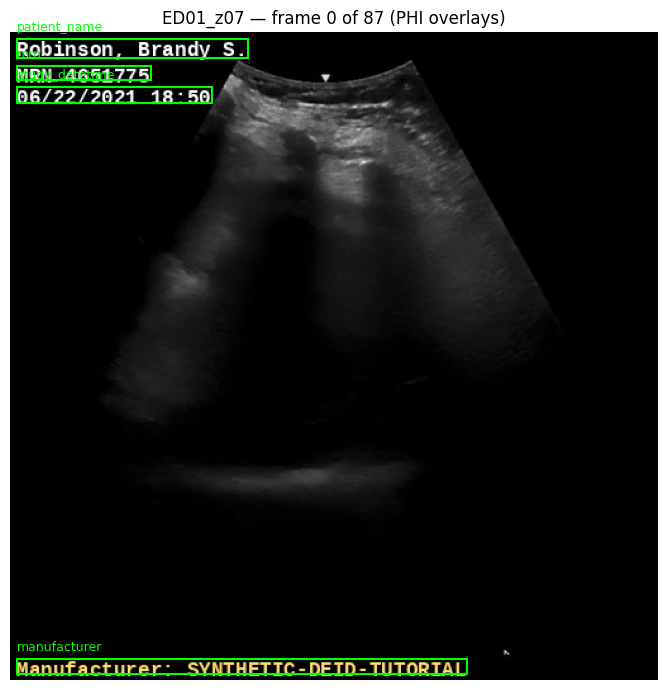

In [20]:
ok_rows = manifest_df[manifest_df["status"] == "ok"]
if len(ok_rows) == 0:
    print("No successful zones to inspect.")
else:
    sample = ok_rows.iloc[0]
    deid_id = sample["deid_patient_id"]
    patient_dir = RUN_DIR / deid_id
    dcm_path = patient_dir / sample["output_dicom_relpath"]

    ds = pydicom.dcmread(dcm_path)
    overlays = pd.read_csv(patient_dir / "phi_overlays.csv")
    overlays = overlays[overlays["zone_key"] == sample["zone_key"]]

    print(f"=== {sample['zone_key']}  ({deid_id}) ===")
    print(f"NumberOfFrames:     {ds.NumberOfFrames}")
    print(f"pixel_array.shape:  {ds.pixel_array.shape}")
    print(f"PatientName:        {ds.PatientName}")
    print(f"PatientID (de-id):  {ds.PatientID}")
    print(f"SeriesDescription:  {ds.SeriesDescription}")
    print(f"StudyInstanceUID:   {ds.StudyInstanceUID}")
    print(f"\nPHI overlays (burned on all {ds.NumberOfFrames} frames):")
    for _, ov in overlays.iterrows():
        bbox = [ov["bbox_x"], ov["bbox_y"], ov["bbox_w"], ov["bbox_h"]] \
               if "bbox_x" in ov else ov.get("bbox")
        print(f"  - {ov['phi_category']:15s} \"{ov['rendered_text']}\"")

    # Visualize frame 0 with PHI boxes
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import ast

    frame0 = ds.pixel_array[0]
    fig, ax = plt.subplots(figsize=(9, 7))
    if frame0.ndim == 3:
        ax.imshow(frame0)             # RGB
    else:
        ax.imshow(frame0, cmap="gray") # grayscale
    for _, ov in overlays.iterrows():
        bbox = ov["bbox"]
        if isinstance(bbox, str):
            bbox = ast.literal_eval(bbox)
        x, y, w, h = bbox
        ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=1.5,
                                        edgecolor="lime", facecolor="none"))
        ax.text(x, y - 4, ov["phi_category"], color="lime", fontsize=9, va="bottom")
    ax.set_title(f"{sample['zone_key']} — frame 0 of {ds.NumberOfFrames} (PHI overlays)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## 13.1. Validation on the RGB output

There should be three equal channels, which means all channels identical: True. That's the proof the file is real RGB and that the content is grayscale-replicated.

In [21]:
ds = pydicom.dcmread(sorted(RUN_DIR.rglob("*.dcm"))[0])
arr = ds.pixel_array

print(f"File:                       {sorted(RUN_DIR.rglob('*.dcm'))[0].name}")
print(f"SamplesPerPixel:            {ds.SamplesPerPixel}")
print(f"PhotometricInterpretation:  {ds.PhotometricInterpretation}")
print(f"pixel_array.shape:          {arr.shape}")
print(f"PixelData bytes:            {len(ds.PixelData):,}")

if arr.ndim == 4:
    # RGB: (num_frames, H, W, 3)
    print(f"Channel means on frame 0:   R={arr[0,:,:,0].mean():.1f}, "
          f"G={arr[0,:,:,1].mean():.1f}, B={arr[0,:,:,2].mean():.1f}")
    identical = (np.array_equal(arr[0,:,:,0], arr[0,:,:,1])
                 and np.array_equal(arr[0,:,:,1], arr[0,:,:,2]))
    print(f"All channels identical:     {identical}")
else:
    # Grayscale: (num_frames, H, W) — no channels to compare
    print(f"Mean intensity on frame 0:  {arr[0].mean():.1f}")
    print(f"(grayscale output — no channel-equality check applicable)")

File:                       ED01_z07_Lung_zone_7.dcm
SamplesPerPixel:            3
PhotometricInterpretation:  RGB
pixel_array.shape:          (87, 512, 512, 3)
PixelData bytes:            68,419,584
Channel means on frame 0:   R=11.6, G=11.4, B=10.8
All channels identical:     False


## 14. DICOM compliance check (dciodvfy)

Validate the written DICOMs against the DICOM standard using `dciodvfy` from [dicom3tools](https://dclunie.com/dicom3tools/). The binary is not bundled here; if it is installed and on `PATH`, this cell runs it over every output DICOM and prints a pass/warn/error summary. If the binary is missing, the cell explains how to install it and skips.

In [22]:
import shutil
import subprocess
import sys


def validate_with_dciodvfy(dicom_files: list[Path]) -> bool:
    """Try dciodvfy (dicom3tools binary) if it's on PATH. Returns True if it ran.

    Not pip-installable; requires the dicom3tools binary to be on PATH.
    """
    binary = shutil.which("dciodvfy")
    if binary is None:
        return False

    print(f"Validating {len(dicom_files)} file(s) with dciodvfy ...\n")
    results = []
    for dcm in dicom_files:
        proc = subprocess.run([binary, str(dcm)], capture_output=True, text=True)
        out = (proc.stdout or "") + (proc.stderr or "")
        n_err = out.lower().count("error")
        n_warn = out.lower().count("warning")
        status = "PASS" if n_err == 0 else "ERROR"
        results.append({
            "file": str(dcm.relative_to(RUN_DIR)),
            "status": status, "errors": n_err, "warnings": n_warn,
        })
        print(f"  [{status}] {dcm.name}  (errors={n_err}, warnings={n_warn})")
        if n_err > 0:
            # Print the actual error lines for diagnosis
            for line in out.splitlines():
                if "error" in line.lower():
                    print(f"      {line.strip()}")

    pd.DataFrame(results).to_csv(RUN_DIR / "dicom_validation.csv", index=False)
    return True


def validate_with_dicom_validator_cli(dicom_files: list[Path]) -> bool:
    """Validate via the dicom-validator CLI (`validate_iods`). Pip-installable.

    Downloads the DICOM standard definitions on first run (cached afterward).
    """
    if shutil.which("validate_iods") is None:
        print("Installing dicom-validator ...")
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "dicom-validator"]
        )
    if shutil.which("validate_iods") is None:
        return False  # install didn't expose the CLI for some reason

    print(f"Validating {len(dicom_files)} file(s) with dicom-validator ...\n")
    results = []
    for dcm in dicom_files:
        proc = subprocess.run(
            ["validate_iods", str(dcm)], capture_output=True, text=True
        )
        out = (proc.stdout or "") + (proc.stderr or "")
        # dicom-validator prints "Error" lines for genuine violations
        error_lines = [ln for ln in out.splitlines() if "error" in ln.lower()
                       and "errors" not in ln.lower()]  # exclude the "Errors" header
        n_err = len(error_lines)
        status = "PASS" if n_err == 0 else "ERROR"
        results.append({
            "file": str(dcm.relative_to(RUN_DIR)),
            "status": status, "issues": n_err,
        })
        print(f"  [{status}] {dcm.name}  (issues={n_err})")
        if n_err > 0:
            for line in error_lines:
                print(f"      {line.strip()}")

    pd.DataFrame(results).to_csv(RUN_DIR / "dicom_validation.csv", index=False)
    return True


def validate_basic_reread(dicom_files: list[Path]) -> None:
    """Minimal fallback: confirm every file re-reads and decodes cleanly.

    Not a full standard-compliance check, but proves the files are structurally
    sound and the pixel data is readable.
    """
    print("Basic check: confirming files re-read cleanly with pydicom ...\n")
    results, ok = [], 0
    for dcm in dicom_files:
        try:
            ds = pydicom.dcmread(dcm)
            _ = ds.pixel_array  # force pixel decode
            results.append({"file": str(dcm.relative_to(RUN_DIR)), "status": "PASS"})
            ok += 1
            print(f"  [PASS] {dcm.name}")
        except Exception as ex:
            results.append({
                "file": str(dcm.relative_to(RUN_DIR)),
                "status": f"ERROR: {ex}",
            })
            print(f"  [ERROR] {dcm.name}: {ex}")

    pd.DataFrame(results).to_csv(RUN_DIR / "dicom_validation.csv", index=False)
    print(f"\n  {ok}/{len(dicom_files)} files re-read successfully.")


def validate_dicoms() -> None:
    """Validate output DICOMs for standard compliance.

    Tries three validators in order of rigor:
      1. dciodvfy (dicom3tools binary) — most rigorous, requires install
      2. dicom-validator (pip CLI) — solid, pip-installable, works on Colab
      3. pydicom re-read — basic structural sanity, always works
    """
    dicom_files = sorted(RUN_DIR.rglob("*.dcm"))
    if not dicom_files:
        print("No DICOM files found to validate.")
        return

    if validate_with_dciodvfy(dicom_files):
        return

    print("dciodvfy not on PATH — trying dicom-validator (pip CLI) ...\n")
    try:
        if validate_with_dicom_validator_cli(dicom_files):
            return
    except Exception as e:
        print(f"dicom-validator could not run ({e}).\n")

    validate_basic_reread(dicom_files)


validate_dicoms()

dciodvfy not on PATH — trying dicom-validator (pip CLI) ...

Installing dicom-validator ...
Validating 12 file(s) with dicom-validator ...

  [PASS] ED01_z07_Lung_zone_7.dcm  (issues=0)
  [PASS] ED01_z08_Lung_zone_8.dcm  (issues=0)
  [PASS] ED01_z09_Lung_zone_9.dcm  (issues=0)
  [PASS] ED01_z10_Lung_zone_10.dcm  (issues=0)
  [PASS] ED02_z01_Lung_zone_1.dcm  (issues=0)
  [PASS] ED02_z02_Lung_zone_2.dcm  (issues=0)
  [PASS] ED02_z03_Lung_zone_3.dcm  (issues=0)
  [PASS] ED02_z04_Lung_zone_4.dcm  (issues=0)
  [PASS] ED02_z07_Lung_zone_7.dcm  (issues=0)
  [PASS] ED02_z08_Lung_zone_8.dcm  (issues=0)
  [PASS] ED02_z09_Lung_zone_9.dcm  (issues=0)
  [PASS] ED02_z10_Lung_zone_10.dcm  (issues=0)
